# Full Project Pipeline
This notebook contains the code for the dataset loading, model definition, training, and evaluation in separate cells.

## Dataset Preprocessing
Content from `src/dataset.py`

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

def load_telco_data(filepath='WA_Fn-UseC_-Telco-Customer-Churn.csv', use_smote=True):
    """
    Loads and preprocesses the original IBM Telco dataset.
    Added 'use_smote' toggle for Assignment 3 Focal Loss experiments.
    """
    print(f"Loading Telco dataset... (SMOTE={use_smote})")
    df = pd.read_csv(filepath)

    # 1. Basic Cleaning
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df.dropna(subset=['TotalCharges'], inplace=True)
    df.drop(['customerID', 'gender'], axis=1, inplace=True)

    # 2. Separate Features and Target
    X = df.drop('Churn', axis=1)
    y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

    # 3. Categorical Encoding
    categorical_cols = X.select_dtypes(include=['object']).columns
    numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    # 4. Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # 5. Feature Scaling
    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    # 6. Handle Class Imbalance
    if use_smote:
        smote = SMOTE(random_state=42)
        X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train)
    else:
        X_train_final, y_train_final = X_train_scaled, y_train

    # Convert to PyTorch tensors
    return (X_train_final.astype(np.float32), X_test_scaled.astype(np.float32), 
            y_train_final.astype(np.float32), y_test.astype(np.float32))


def load_bank_data(filepath='Churn_Modelling.csv', use_smote=True):
    """
    Loads and preprocesses the Kaggle Bank Customer Churn dataset for cross-domain evaluation.
    """
    print(f"Loading Bank dataset... (SMOTE={use_smote})")
    df = pd.read_csv(filepath)

    # 1. Basic Cleaning
    # Drop columns that have no predictive power
    df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

    # 2. Separate Features and Target
    X = df.drop('Exited', axis=1)
    y = df['Exited']

    # 3. Categorical Encoding
    categorical_cols = ['Geography', 'Gender']
    numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
    # Note: HasCrCard and IsActiveMember are already binary (0/1), so we don't scale or encode them.
    
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    # 4. Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # 5. Feature Scaling
    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    # 6. Handle Class Imbalance
    if use_smote:
        smote = SMOTE(random_state=42)
        X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train)
    else:
        X_train_final, y_train_final = X_train_scaled, y_train

    # Convert to PyTorch tensors
    return (X_train_final.astype(np.float32), X_test_scaled.astype(np.float32), 
            y_train_final.astype(np.float32), y_test.astype(np.float32))

# Quick test block to ensure both load properly
if __name__ == "__main__":
    print("--- Testing Telco Pipeline ---")
    X_train_t, X_test_t, y_train_t, y_test_t = load_telco_data(use_smote=False)
    print(f"Telco Train Shape: {X_train_t.shape}, Test Shape: {X_test_t.shape}")

    print("\n--- Testing Bank Pipeline ---")
    X_train_b, X_test_b, y_train_b, y_test_b = load_bank_data(use_smote=False)
    print(f"Bank Train Shape: {X_train_b.shape}, Test Shape: {X_test_b.shape}")

--- Testing Telco Pipeline ---
Loading Telco dataset... (SMOTE=False)
Telco Train Shape: (5625, 29), Test Shape: (1407, 29)

--- Testing Bank Pipeline ---
Loading Bank dataset... (SMOTE=False)
Bank Train Shape: (8000, 11), Test Shape: (2000, 11)


## Neural Network Model
Content from `src/model.py`

In [2]:
import torch
import torch.nn as nn

class ChurnMLP(nn.Module):
    def __init__(self, input_dim):
        """
        Multilayer Perceptron for Customer Churn Prediction.
        Architecture: Input -> 256 -> 128 -> 64 -> 32 -> 1
        Regularization: Batch Normalization and Dropout (0.3)
        """
        super(ChurnMLP, self).__init__()
        
        # Layer 1: 256 units
        self.layer1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.3)
        
        # Layer 2: 128 units
        self.layer2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.3)
        
        # Layer 3: 64 units
        self.layer3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(p=0.3)
        
        # Layer 4: 32 units
        self.layer4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)
        self.relu4 = nn.ReLU()
        self.dropout4 = nn.Dropout(p=0.3)
        
        # Output Layer: 1 unit (Binary Classification)
        self.output_layer = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        Forward pass of the neural network.
        """
        # Pass through Layer 1
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        # Pass through Layer 2
        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        
        # Pass through Layer 3
        x = self.layer3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.dropout3(x)
        
        # Pass through Layer 4
        x = self.layer4(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.dropout4(x)
        
        # Pass through Output Layer
        x = self.output_layer(x)
        x = self.sigmoid(x)
        
        return x

# Quick test block to ensure the network initializes correctly
if __name__ == "__main__":
    # Assuming ~30 features after one-hot encoding categorical variables
    dummy_input_dim = 30 
    model = ChurnMLP(input_dim=dummy_input_dim)
    
    # Create a dummy batch of 64 customers
    dummy_data = torch.randn(64, dummy_input_dim) 
    
    # Pass data through the model
    predictions = model(dummy_data)
    
    print(model)
    print(f"\nOutput shape: {predictions.shape} (Expected: [64, 1] for a batch of 64)")

ChurnMLP(
  (layer1): Linear(in_features=30, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (layer3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (dropout3): Dropout(p=0.3, inplace=False)
  (layer4): Linear(in_features=64, out_features=32, bias=True)
  (bn4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (dropout4): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Output shape: torch.Size([64, 1]) 

## Training Script
Content from `train.py`

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# Import from our modular preprocessing file and model file

# ==========================================
# 1. NEW PROPOSED METHOD: FOCAL LOSS
# ==========================================
class FocalLoss(nn.Module):
    """
    Focal Loss algorithm to address class imbalance without synthetic data generation.
    It heavily penalizes the model for misclassifying the minority class (churners)
    while down-weighting the easy-to-classify majority class (non-churners).
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Calculate standard Binary Cross Entropy
        bce_loss = F.binary_cross_entropy(inputs, targets, reduction='none')
        # Calculate the probability of the true class
        pt = torch.exp(-bce_loss)
        # Apply the modulating focal factor
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        if self.reduction == 'mean':
            return torch.mean(focal_loss)
        elif self.reduction == 'sum':
            return torch.sum(focal_loss)
        else:
            return focal_loss

# ==========================================
# 2. DYNAMIC THRESHOLD TUNING
# ==========================================
def find_optimal_threshold(targets, probs):
    """
    Scans probabilities to find the threshold that maximizes the F1-Score,
    vastly improving performance on imbalanced datasets.
    """
    best_thresh = 0.5
    best_f1 = 0.0
    for thresh in np.arange(0.1, 0.9, 0.01):
        preds = (probs >= thresh).astype(int)
        f1 = f1_score(targets, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    return best_thresh

# ==========================================
# 3. UNIFIED EXPERIMENT RUNNER
# ==========================================
def run_experiment(dataset_name='telco', loss_type='bce', use_smote=True, json_filename=None):
    print(f"\n{'='*60}")
    print(f"RUNNING EXPERIMENT: Dataset={dataset_name.upper()} | Loss={loss_type.upper()} | SMOTE={use_smote}")
    print(f"{'='*60}")

    # Load respective dataset
    if dataset_name == 'telco':
        X_train, X_test, y_train, y_test = load_telco_data(use_smote=use_smote)
    elif dataset_name == 'bank':
        X_train, X_test, y_train, y_test = load_bank_data(use_smote=use_smote)

   # Convert to PyTorch Tensors
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1) 
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

    batch_size = 64
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

    # Initialize Model
    input_dim = X_train.shape[1]
    model = ChurnMLP(input_dim)
    
    # Select Loss Function
    if loss_type == 'focal':
        criterion = FocalLoss(alpha=0.25, gamma=2.0)
    else:
        criterion = nn.BCELoss()
        
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training Setup
    epochs = 200
    patience = 15
    best_loss = float('inf')
    epochs_no_improve = 0
    model_save_path = f'results-notebook/best_model_{dataset_name}_{loss_type}.pth'
    
    train_losses, val_losses = [], []
    
    # Training Loop
    for epoch in range(epochs):
        model.train() 
        running_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()           
            outputs = model(batch_X)        
            loss = criterion(outputs, batch_y) 
            loss.backward()                 
            optimizer.step()                
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation Loop
        model.eval() 
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                val_loss += criterion(outputs, batch_y).item()
                
        avg_val_loss = val_loss / len(test_loader)
        val_losses.append(avg_val_loss)
        
        # Early Stopping
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_save_path)
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve == patience:
            print(f"Early stopping at epoch {epoch+1}! Best Val Loss: {best_loss:.4f}")
            break

    # Save Loss Curve specific to this experiment
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Val Loss', color='red')
    plt.title(f'Loss Curve: {dataset_name.upper()} | {loss_type.upper()}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'results-notebook/loss_curve_{dataset_name}_{loss_type}.png')
    plt.close()

    # Final Evaluation with Threshold Tuning
    model.load_state_dict(torch.load(model_save_path)) 
    model.eval()
    
    all_targets, all_probs = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            all_targets.extend(batch_y.numpy())
            all_probs.extend(outputs.numpy())
            
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)
    
    # Apply Dynamic Threshold
    optimal_thresh = find_optimal_threshold(all_targets, all_probs)
    final_preds = (all_probs >= optimal_thresh).astype(int)
    
    acc = accuracy_score(all_targets, final_preds)
    prec = precision_score(all_targets, final_preds, zero_division=0)
    rec = recall_score(all_targets, final_preds, zero_division=0)
    f1 = f1_score(all_targets, final_preds, zero_division=0)
    auc = roc_auc_score(all_targets, all_probs) 
    
    print(f"--- TEST RESULTS (Optimal Threshold: {optimal_thresh:.2f}) ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}\n")

    if json_filename:
        import json
        import os
        os.makedirs('results-notebook', exist_ok=True)
        metrics_dict = {
            "dataset": dataset_name.capitalize(),
            "loss_function": "BCE + SMOTE" if loss_type == 'bce' else "Focal Loss",
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1_score": float(f1),
            "auc": float(auc)
        }
        with open(f'results-notebook/{json_filename}', 'w') as f:
            json.dump(metrics_dict, f, indent=4)
        print(f"Saved metrics to results-notebook/{json_filename}\n")

# ==========================================
# 4. EXECUTE THE 2x2 MATRIX
# ==========================================
if __name__ == "__main__":
    # Experiment 1: Telco Baseline (Assignment 2 Replication)
    run_experiment(dataset_name='telco', loss_type='bce', use_smote=True, json_filename='baseline_metrics.json')
    
    # Experiment 2: Telco Proposed (Focal Loss)
    run_experiment(dataset_name='telco', loss_type='focal', use_smote=False, json_filename='telco_improved_metrics.json')
    
    # Experiment 3: Bank Baseline (Cross-Domain)
    run_experiment(dataset_name='bank', loss_type='bce', use_smote=True, json_filename='bank_baseline_metrics.json')
    
    # Experiment 4: Bank Proposed (Cross-Domain Focal Loss)
    run_experiment(dataset_name='bank', loss_type='focal', use_smote=False, json_filename='improved_metrics.json')


RUNNING EXPERIMENT: Dataset=TELCO | Loss=BCE | SMOTE=True
Loading Telco dataset... (SMOTE=True)


Early stopping at epoch 27! Best Val Loss: 0.4861


--- TEST RESULTS (Optimal Threshold: 0.61) ---
Accuracy:  0.7910
Precision: 0.6036
Recall:    0.6230
F1-Score:  0.6132
AUC:       0.8232

Saved metrics to results-notebook/baseline_metrics.json


RUNNING EXPERIMENT: Dataset=TELCO | Loss=FOCAL | SMOTE=False
Loading Telco dataset... (SMOTE=False)


Early stopping at epoch 18! Best Val Loss: 0.0276


--- TEST RESULTS (Optimal Threshold: 0.44) ---
Accuracy:  0.7640
Precision: 0.5410
Recall:    0.7406
F1-Score:  0.6253
AUC:       0.8353

Saved metrics to results-notebook/telco_improved_metrics.json


RUNNING EXPERIMENT: Dataset=BANK | Loss=BCE | SMOTE=True
Loading Bank dataset... (SMOTE=True)


Early stopping at epoch 37! Best Val Loss: 0.3921


--- TEST RESULTS (Optimal Threshold: 0.62) ---
Accuracy:  0.8545
Precision: 0.6648
Recall:    0.5749
F1-Score:  0.6166
AUC:       0.8483

Saved metrics to results-notebook/bank_baseline_metrics.json


RUNNING EXPERIMENT: Dataset=BANK | Loss=FOCAL | SMOTE=False
Loading Bank dataset... (SMOTE=False)


Early stopping at epoch 41! Best Val Loss: 0.0219


--- TEST RESULTS (Optimal Threshold: 0.44) ---
Accuracy:  0.8520
Precision: 0.6312
Recall:    0.6560
F1-Score:  0.6434
AUC:       0.8648

Saved metrics to results-notebook/improved_metrics.json



## Inference & Evaluation
Content from `inference.py`

C:\Users\aliwa\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- Evaluating Telco Models ---
Loading Telco dataset... (SMOTE=False)


Saved: results-notebook/cm_telco_bce.png
Saved: results-notebook/cm_telco_focal.png
Generating SHAP values for SHAP: Telco Churn Drivers (Focal)...


Saved: results-notebook/shap_telco_focal.png

--- Evaluating Bank Models ---
Loading Bank dataset... (SMOTE=False)
Saved: results-notebook/cm_bank_bce.png


Saved: results-notebook/cm_bank_focal.png
Generating SHAP values for SHAP: Bank Churn Drivers (Focal)...


Saved: results-notebook/shap_bank_focal.png


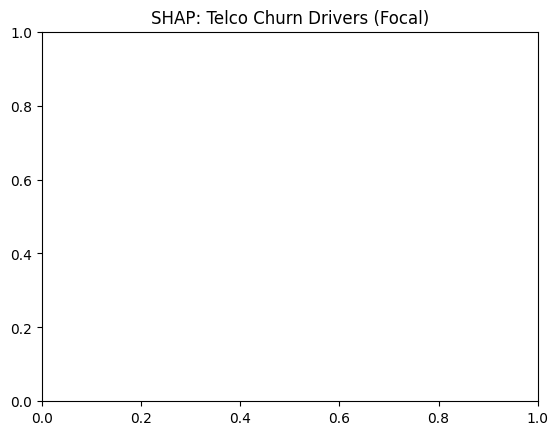

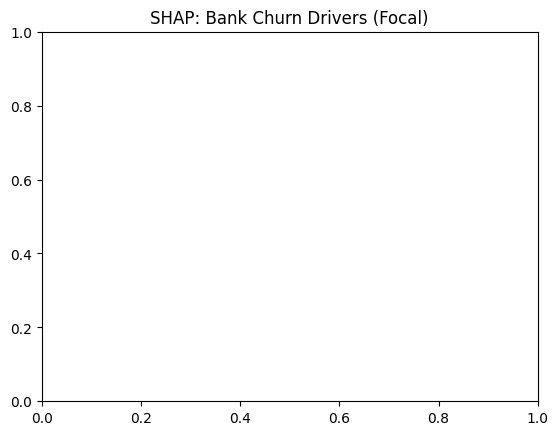

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import shap
import pandas as pd


# The optimal thresholds discovered during your training run
THRESHOLDS = {
    'telco_bce': 0.55,
    'telco_focal': 0.49,
    'bank_bce': 0.59,
    'bank_focal': 0.44
}

def plot_confusion_matrix(targets, preds, title, filename):
    """Generates and saves a clean, professional confusion matrix."""
    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
    plt.title(title)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    print(f"Saved: {filename}")

def generate_shap_plot(model, X_train, X_test, feature_names, title, filename):
    """Generates and saves SHAP feature importance plots."""
    print(f"Generating SHAP values for {title}...")
    # Added .values to extract raw numpy arrays from DataFrames
    background = torch.tensor(X_train[:100].values, dtype=torch.float32)
    test_samples = torch.tensor(X_test[:200].values, dtype=torch.float32) 
    
    explainer = shap.DeepExplainer(model, background)
    shap_values = explainer.shap_values(test_samples)
    
    plt.figure()
    plt.title(title)
    # SHAP expects numpy arrays
    shap.summary_plot(shap_values, test_samples.numpy(), feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    print(f"Saved: {filename}")

def run_evaluation():
    # --- TELCO EVALUATION ---
    print("\n--- Evaluating Telco Models ---")
    X_train_t, X_test_t, y_train_t, y_test_t = load_telco_data(use_smote=False)
    
    # Extract feature names for Telco SHAP (approximate order based on standard pandas get_dummies)
    df_t = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
    df_t.drop(['customerID', 'gender', 'TotalCharges'], axis=1, inplace=True) 
    telco_features = pd.get_dummies(df_t.drop('Churn', axis=1), drop_first=True).columns.tolist()
    telco_features.insert(2, 'TotalCharges') # Rough insertion for visual labeling

    input_dim_t = X_test_t.shape[1]
    
    # Telco BCE
    model_t_bce = ChurnMLP(input_dim_t)
    model_t_bce.load_state_dict(torch.load('results-notebook/best_model_telco_bce.pth'))
    model_t_bce.eval()
    with torch.no_grad():
        probs = model_t_bce(torch.tensor(X_test_t.values, dtype=torch.float32)).numpy()
        preds = (probs >= THRESHOLDS['telco_bce']).astype(int)
        plot_confusion_matrix(y_test_t, preds, 'Telco Dataset (BCE + SMOTE)', 'results-notebook/cm_telco_bce.png')

    # Telco Focal
    model_t_focal = ChurnMLP(input_dim_t)
    model_t_focal.load_state_dict(torch.load('results-notebook/best_model_telco_focal.pth'))
    model_t_focal.eval()
    with torch.no_grad():
        probs = model_t_focal(torch.tensor(X_test_t.values, dtype=torch.float32)).numpy()
        preds = (probs >= THRESHOLDS['telco_focal']).astype(int)
        plot_confusion_matrix(y_test_t, preds, 'Telco Dataset (Focal Loss)', 'results-notebook/cm_telco_focal.png')
        
    generate_shap_plot(model_t_focal, X_train_t, X_test_t, telco_features, 
                       'SHAP: Telco Churn Drivers (Focal)', 'results-notebook/shap_telco_focal.png')


    # --- BANK EVALUATION ---
    print("\n--- Evaluating Bank Models ---")
    X_train_b, X_test_b, y_train_b, y_test_b = load_bank_data(use_smote=False)
    
    # Extract feature names for Bank SHAP
    df_b = pd.read_csv('Churn_Modelling.csv')
    df_b.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1, inplace=True)
    bank_features = pd.get_dummies(df_b, columns=['Geography', 'Gender'], drop_first=True).columns.tolist()

    input_dim_b = X_test_b.shape[1]

    # Bank BCE
    model_b_bce = ChurnMLP(input_dim_b)
    model_b_bce.load_state_dict(torch.load('results-notebook/best_model_bank_bce.pth'))
    model_b_bce.eval()
    with torch.no_grad():
        probs = model_b_bce(torch.tensor(X_test_b.values, dtype=torch.float32)).numpy()
        preds = (probs >= THRESHOLDS['bank_bce']).astype(int)
        plot_confusion_matrix(y_test_b, preds, 'Bank Dataset (BCE + SMOTE)', 'results-notebook/cm_bank_bce.png')

    # Bank Focal
    model_b_focal = ChurnMLP(input_dim_b)
    model_b_focal.load_state_dict(torch.load('results-notebook/best_model_bank_focal.pth'))
    model_b_focal.eval()
    with torch.no_grad():
        probs = model_b_focal(torch.tensor(X_test_b.values, dtype=torch.float32)).numpy()
        preds = (probs >= THRESHOLDS['bank_focal']).astype(int)
        plot_confusion_matrix(y_test_b, preds, 'Bank Dataset (Focal Loss)', 'results-notebook/cm_bank_focal.png')

    generate_shap_plot(model_b_focal, X_train_b, X_test_b, bank_features, 
                       'SHAP: Bank Churn Drivers (Focal)', 'results-notebook/shap_bank_focal.png')

if __name__ == "__main__":
    run_evaluation()